<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [5]:
# YOUR CODE HERE
df = pd.read_csv('./data/residents.csv', parse_dates=['date'],date_format='%m-%Y')
df.head(10)

,date,residents
0,1971-04-01,13067.3
1,1971-07-01,13130.5
2,1971-10-01,13198.4
3,1972-01-01,13254.2
4,1972-04-01,13303.7
5,1972-07-01,13353.9
6,1972-10-01,13409.3
7,1973-01-01,13459.2
8,1973-04-01,13504.5
9,1973-07-01,13552.6


### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [6]:
# YOUR CODE HERE
df_eda = df.iloc[:81].copy()
holdout_df = df.iloc[81:].copy()

print('df_eda shape:', df_eda.shape)
print('holdout_df shape:', holdout_df.shape)
df_eda.tail()

df_eda shape: (81, 2)
holdout_df shape: (8, 2)


,date,residents
76,1990-04-01,17085.4
77,1990-07-01,17106.9
78,1990-10-01,17169.4
79,1991-01-01,17239.4
80,1991-04-01,17292.0


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

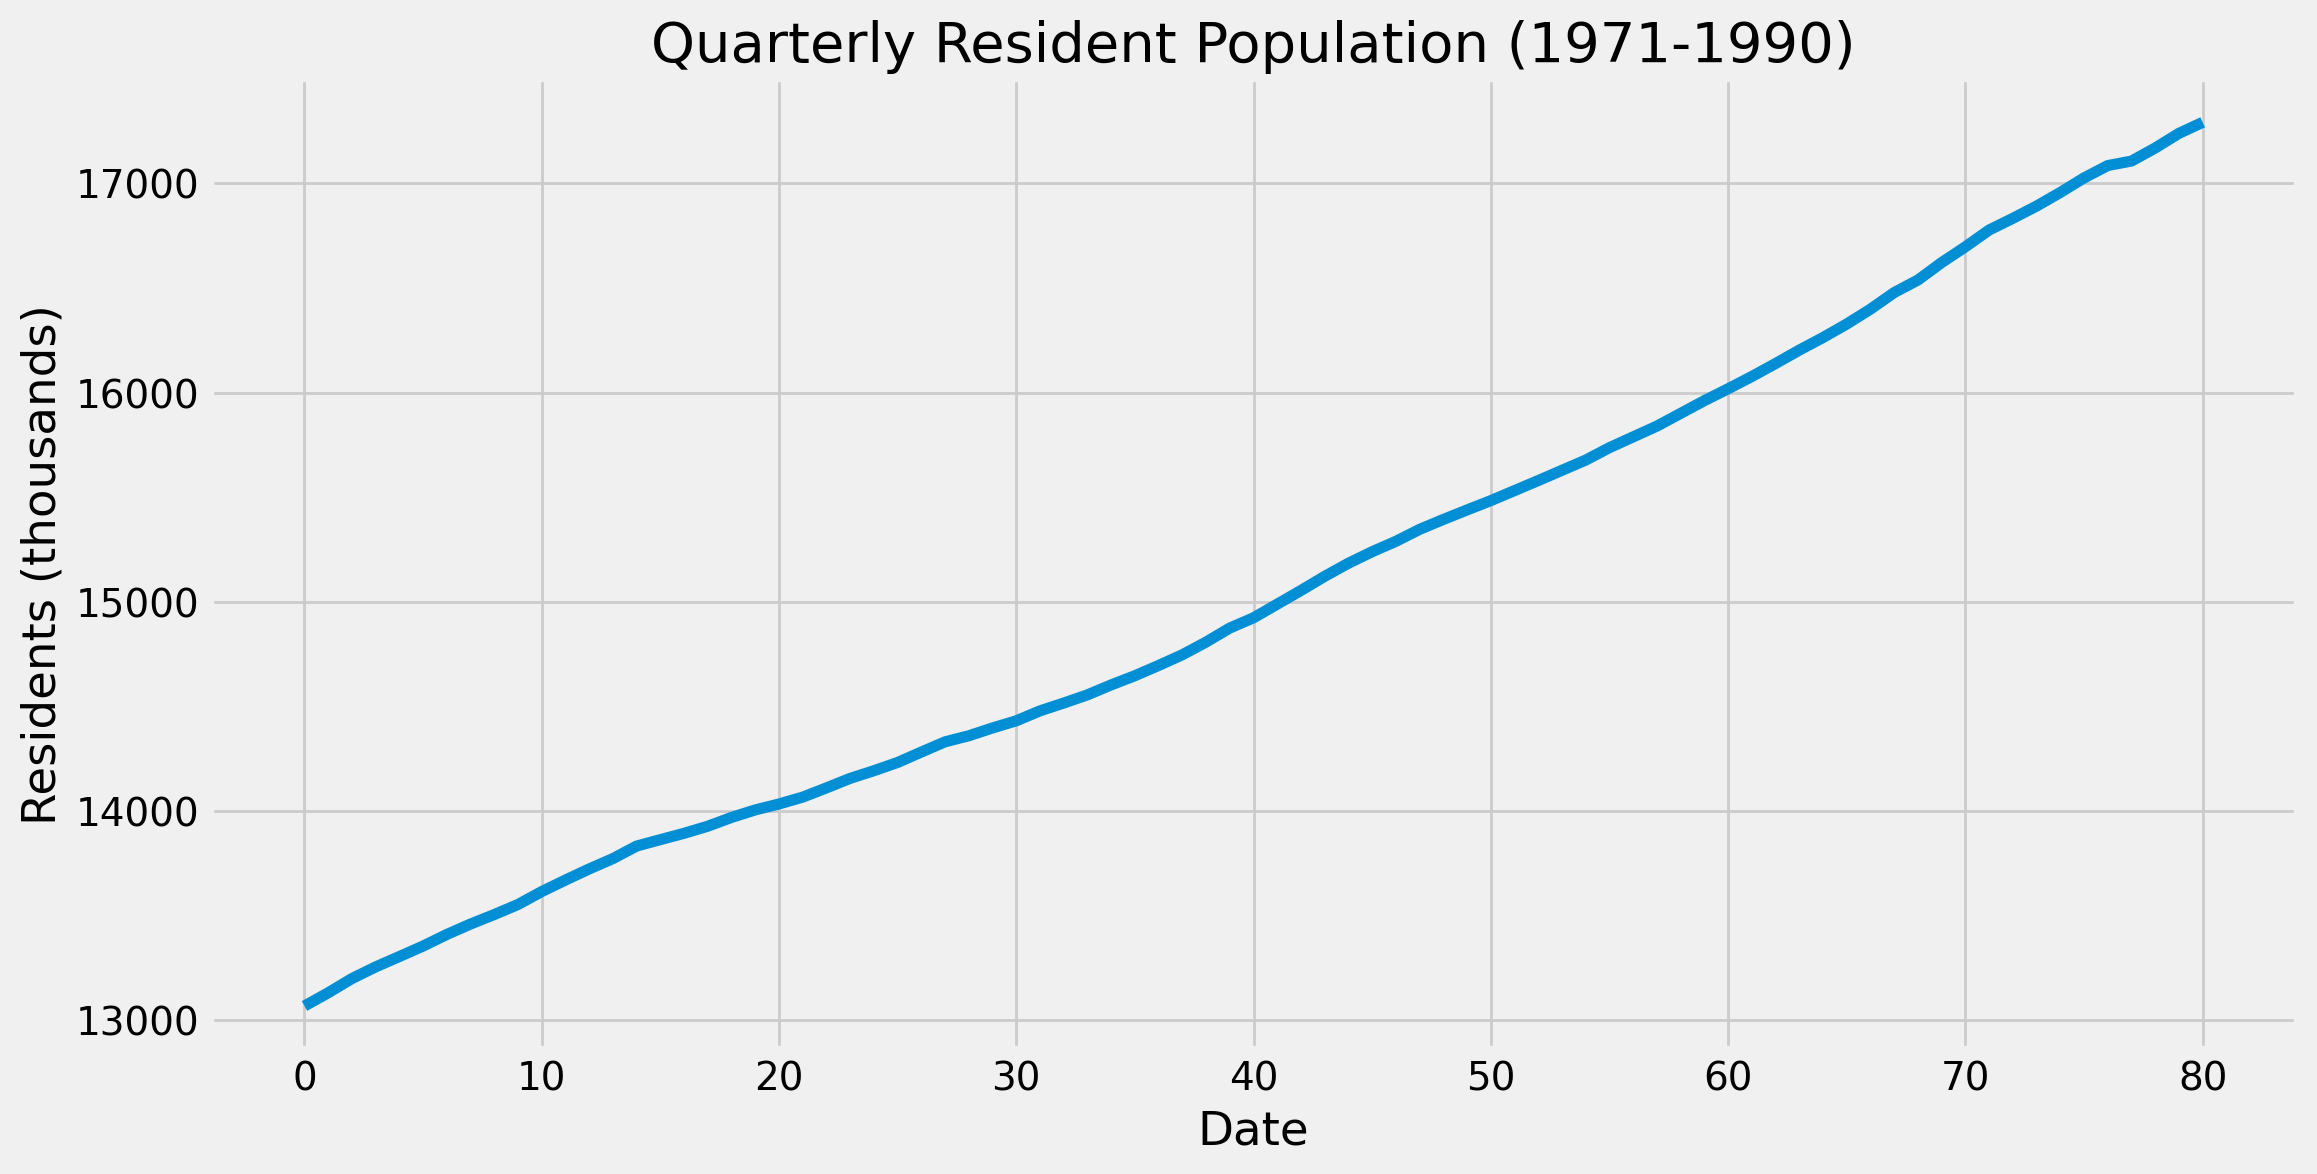

In [7]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(12, 6))
df_eda['residents'].plot(ax=ax)
ax.set_title('Quarterly Resident Population (1971-1990)')
ax.set_ylabel('Residents (thousands)')
ax.set_xlabel('Date')
plt.show()

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

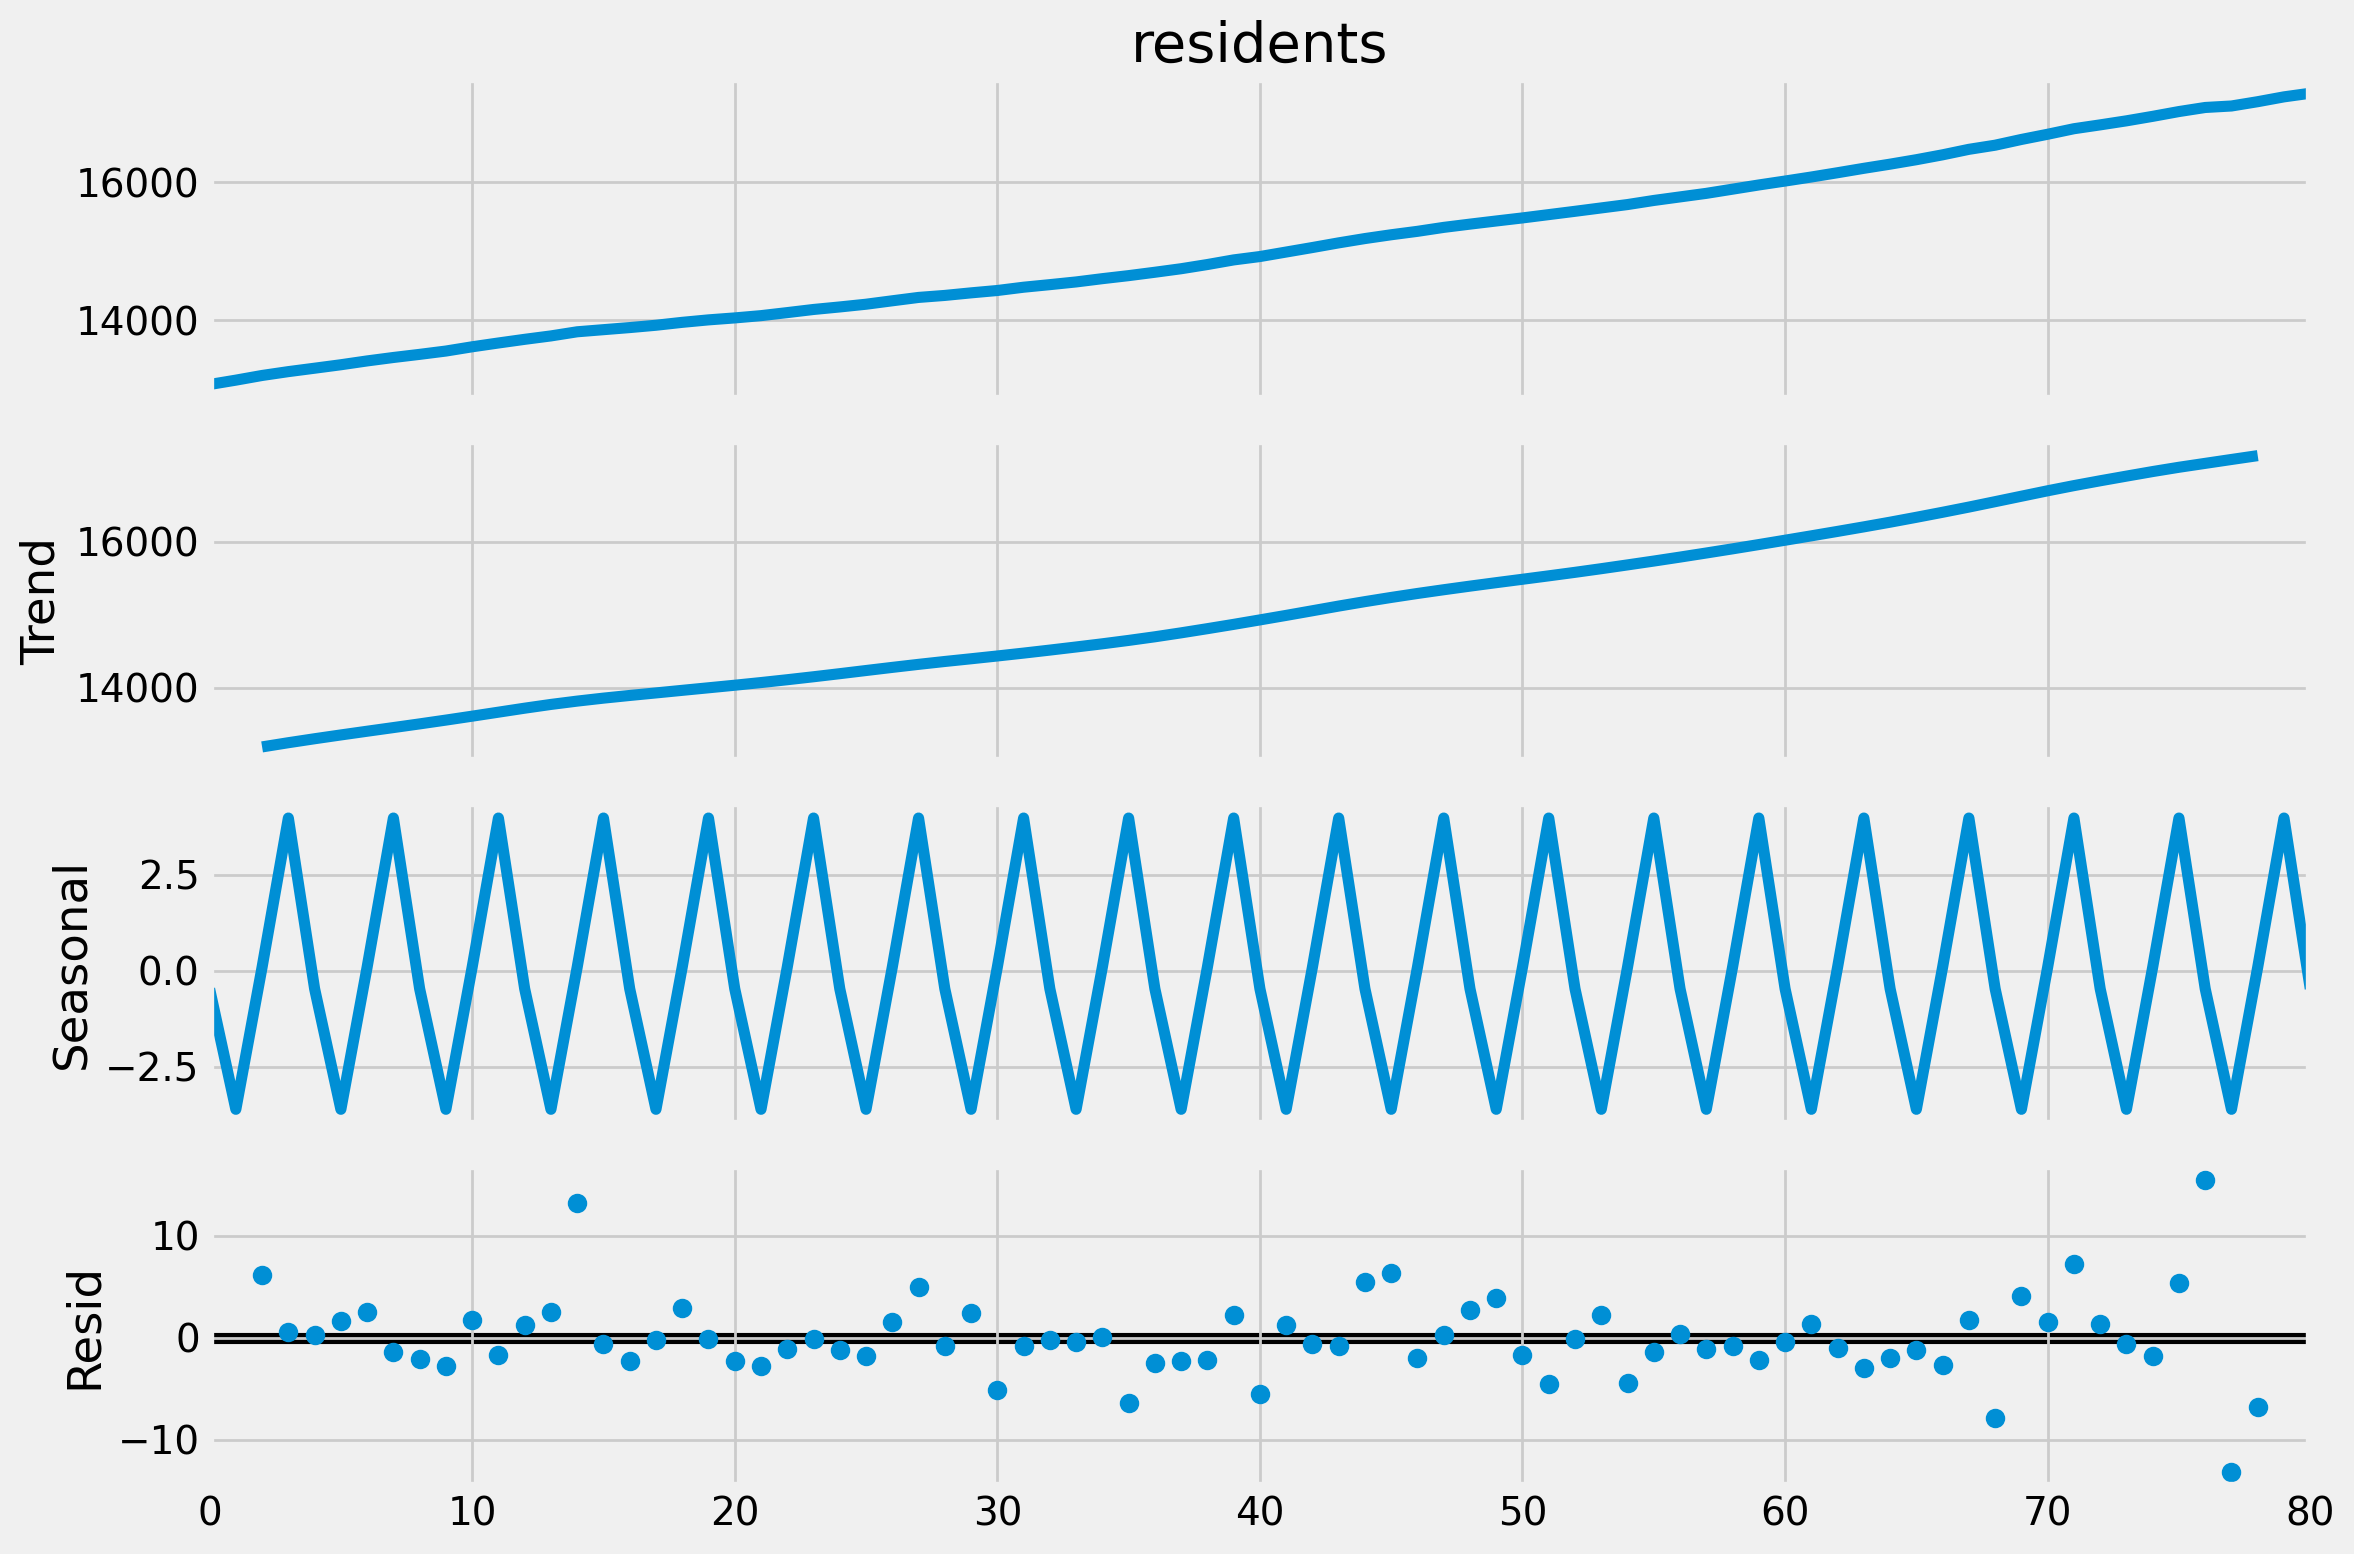

In [8]:
# YOUR CODE HERE
decomposition = seasonal_decompose(df_eda['residents'], period=4, model='additive')

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

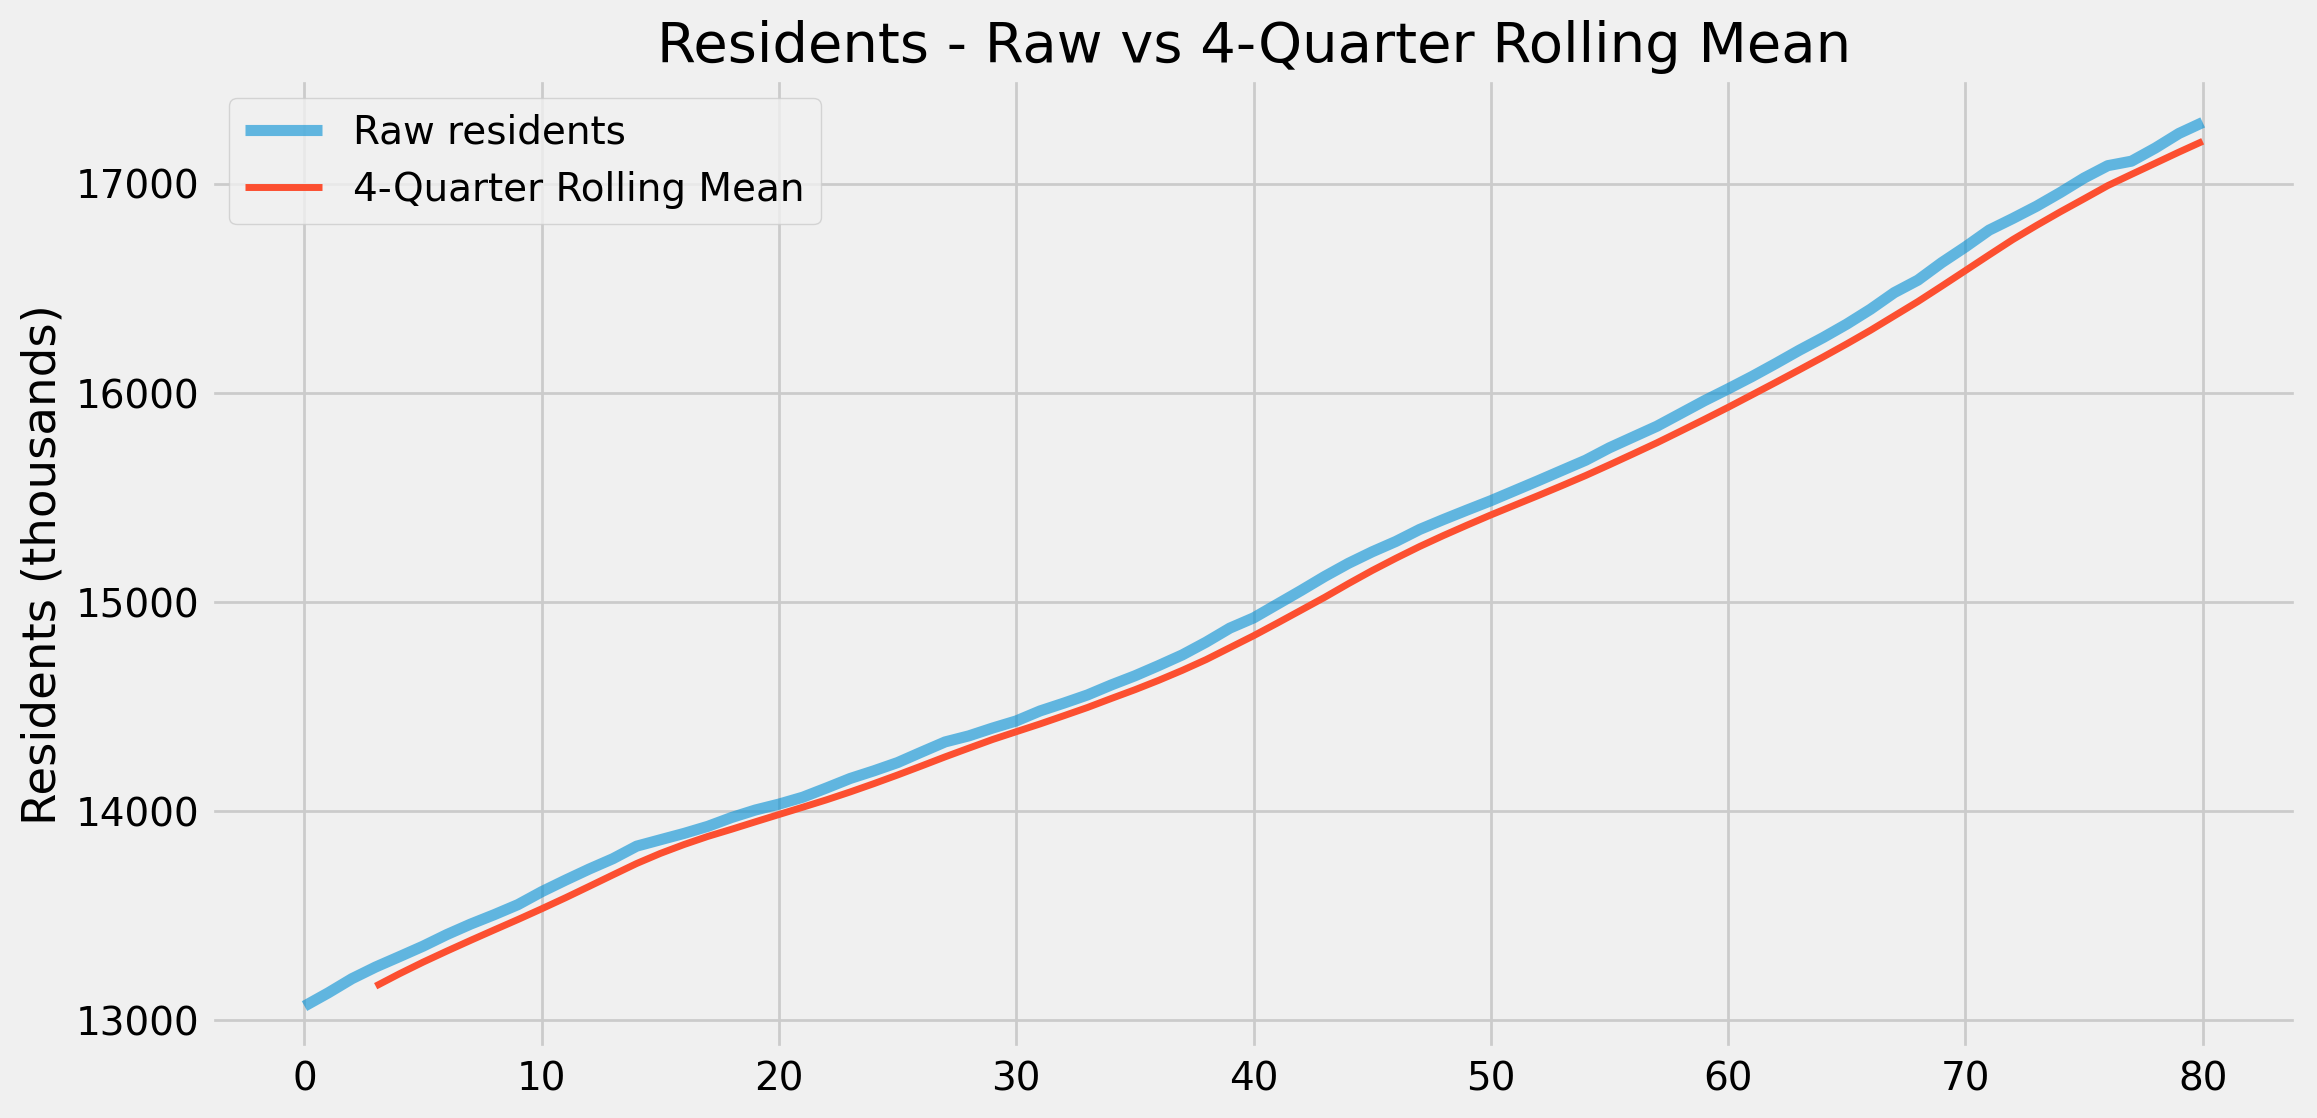

In [9]:
# YOUR CODE HERE
rolling_mean = df_eda['residents'].rolling(window=4).mean()

fig, ax = plt.subplots(figsize=(12, 6))
df_eda['residents'].plot(ax=ax, label='Raw residents', alpha=0.6)
rolling_mean.plot(ax=ax, label='4-Quarter Rolling Mean', linewidth=2.5)
ax.set_title('Residents - Raw vs 4-Quarter Rolling Mean')
ax.set_ylabel('Residents (thousands)')
ax.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

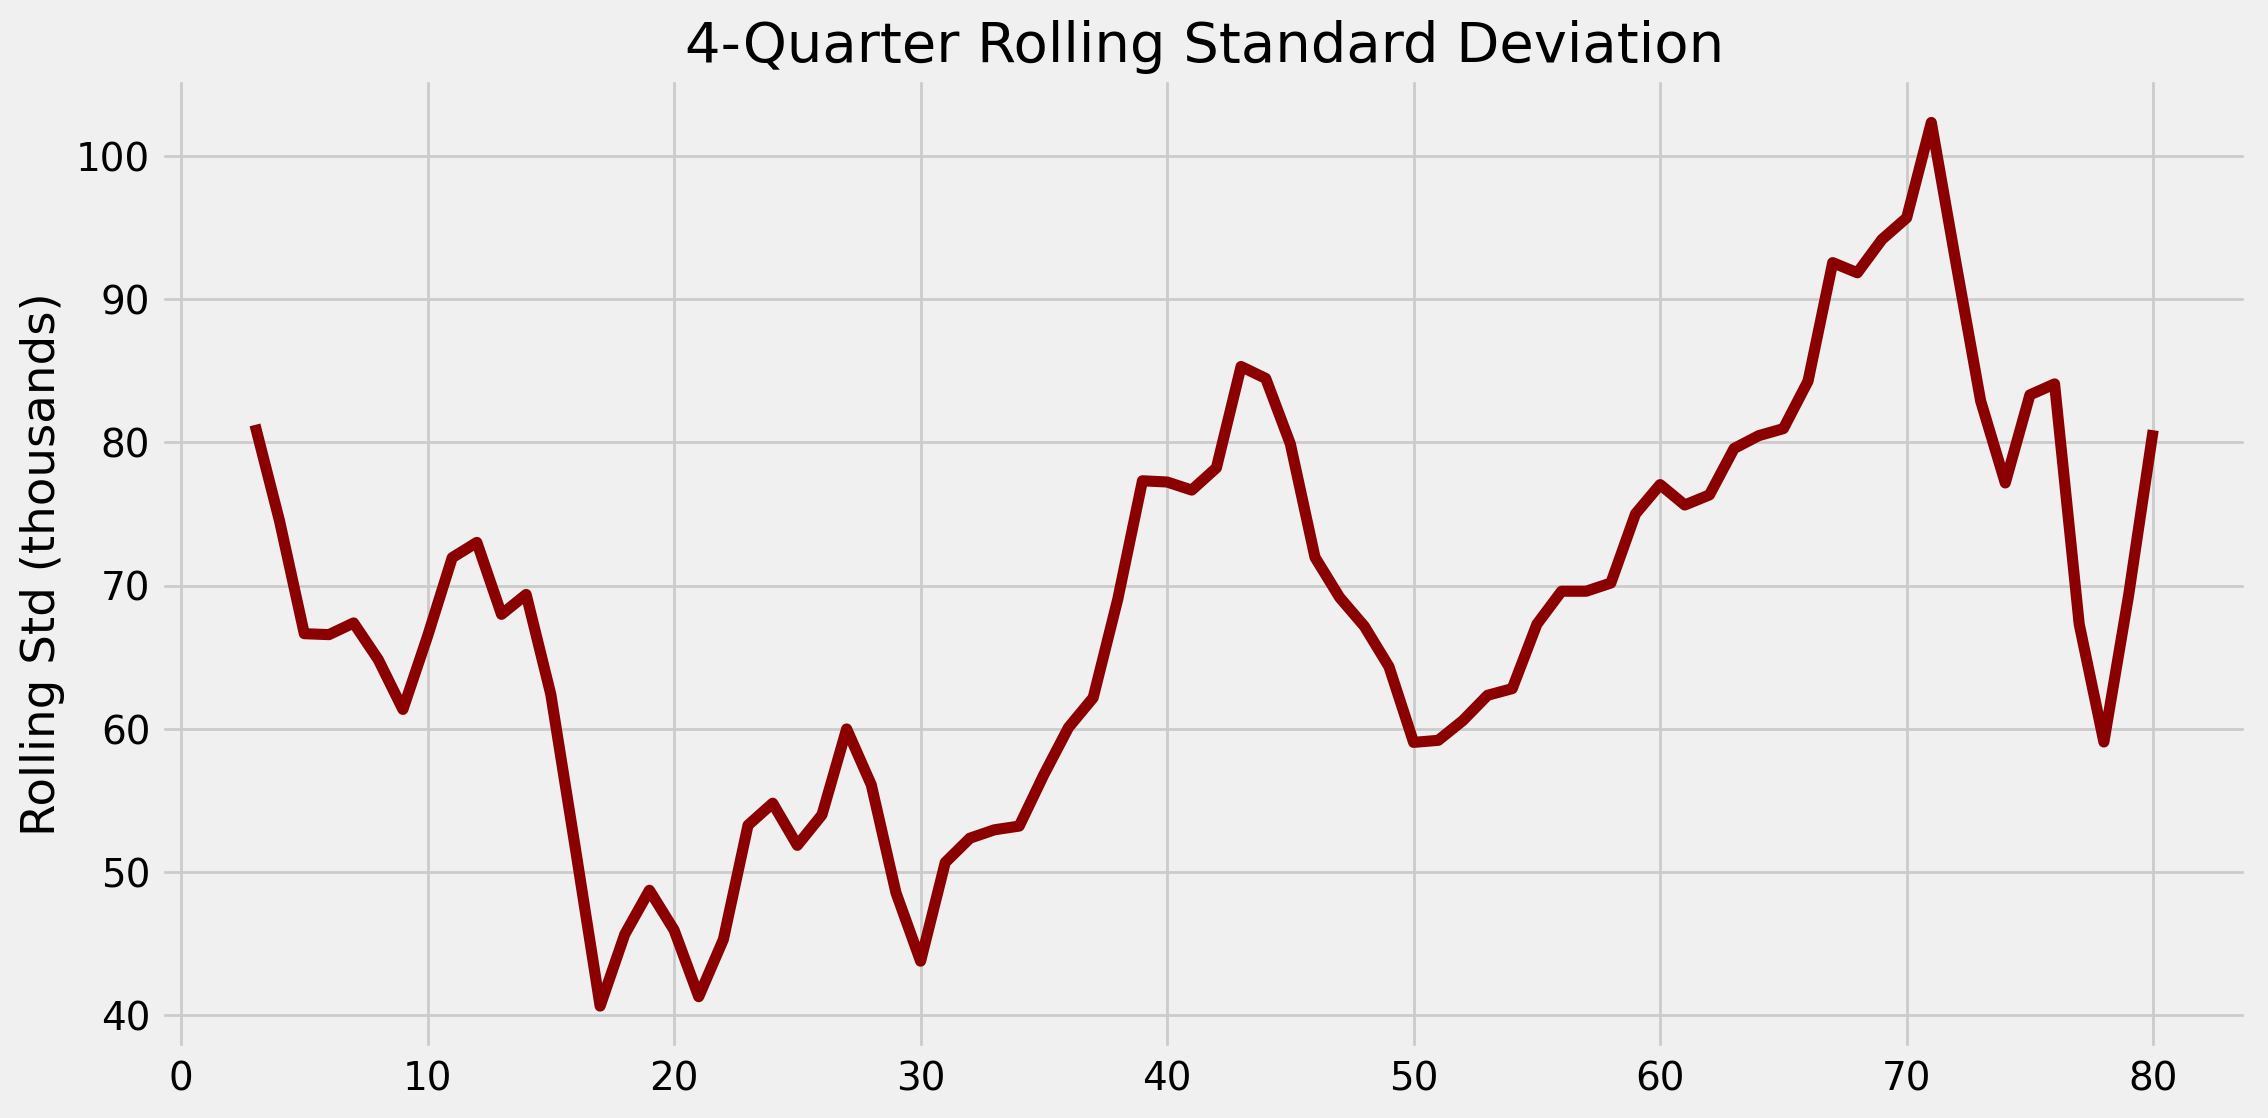

In [10]:
# YOUR CODE HERE
rolling_std = df_eda['residents'].rolling(window=4).std()

fig, ax = plt.subplots(figsize=(12, 6))
rolling_std.plot(ax=ax, color='darkred')
ax.set_title('4-Quarter Rolling Standard Deviation')
ax.set_ylabel('Rolling Std (thousands)')
plt.show()

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [11]:
def adf_test(series):
    """
    Pass in a time series, and prints an ADF report.
    """
    result = adfuller(series.dropna())

    print('ADF Test Statistic : {:.4f}'.format(result[0]))
    print('p-value            : {:.4f}'.format(result[1]))
    print('# Lags Used        : {}'.format(result[2]))
    print('# Observations Used: {}'.format(result[3]))
    print('Critical Values:')
    for key, value in result[4].items():
        print('    {} : {:.4f}'.format(key, value))

    if result[1] <= 0.05:
        print('\n=> p-value <= 0.05: Reject H0. The series IS stationary.')
    else:
        print('\n=> p-value > 0.05: Fail to reject H0. The series is NOT stationary.')
    # YOUR CODE HERE
    

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [12]:
# YOUR CODE HERE
print('===== Raw series =====')
adf_test(df_eda['residents'])

print('\n===== First difference =====')
adf_test(df_eda['residents'].diff())


===== Raw series =====
ADF Test Statistic : 1.8104
p-value            : 0.9984
# Lags Used        : 6
# Observations Used: 74
Critical Values:
    1% : -3.5220
    5% : -2.9015
    10% : -2.5881

=> p-value > 0.05: Fail to reject H0. The series is NOT stationary.

===== First difference =====
ADF Test Statistic : -2.5056
p-value            : 0.1141
# Lags Used        : 5
# Observations Used: 74
Critical Values:
    1% : -3.5220
    5% : -2.9015
    10% : -2.5881

=> p-value > 0.05: Fail to reject H0. The series is NOT stationary.


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [13]:
# YOUR CODE HERE
adf_test(df_eda['residents'].diff().diff())


ADF Test Statistic : -3.1483
p-value            : 0.0232
# Lags Used        : 4
# Observations Used: 74
Critical Values:
    1% : -3.5220
    5% : -2.9015
    10% : -2.5881

=> p-value <= 0.05: Reject H0. The series IS stationary.


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

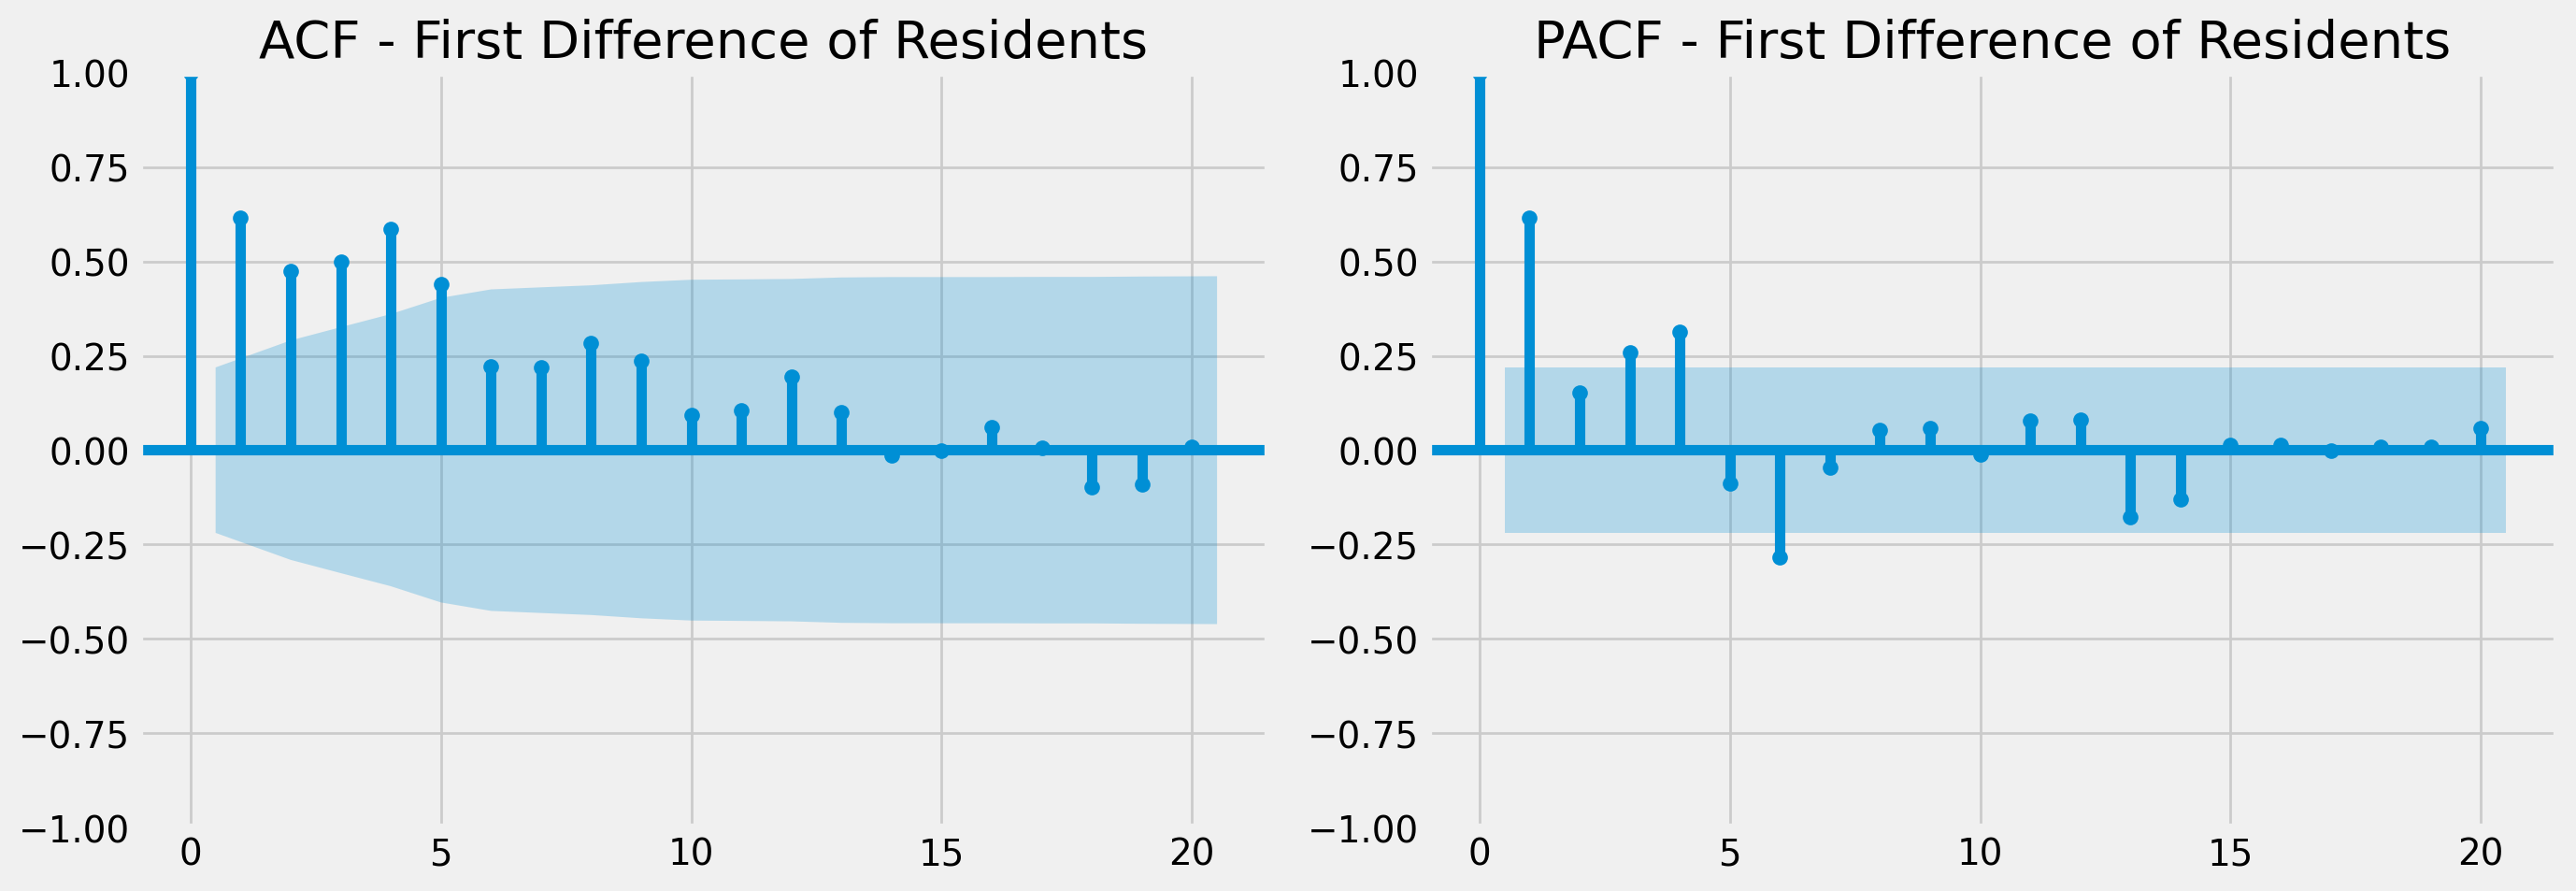

In [14]:
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df_eda['residents'].diff().dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF - First Difference of Residents')

plot_pacf(df_eda['residents'].diff().dropna(), lags=20, ax=axes[1])
axes[1].set_title('PACF - First Difference of Residents')

plt.tight_layout()
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

Based on the ACF plot for the First Difference of Residents:

Strongest Spike (excluding Lag 0):

The strongest positive autocorrelation spike occurs at Lag 1 (value around ~0.62).

There are also prominent secondary spikes at Lag 4 (~0.60) and Lag 3 (~0.50).

What this tells you about the data:

High Short-Term Autocorrelation: The strong spike at Lag 1 indicates that even after taking the first difference, a change in one time period (month/quarter) is strongly positively correlated with the immediate next period.

Need for Moving Average (MA) / Further Stationarity Adjustments: In time-series modeling (ARIMA), a significant spike at Lag 1 in the ACF plot suggests including an MA(1) term or further seasonal differencing.

Seasonal / Periodical Patterns: The repeating pattern/spikes at regular intervals (especially elevated around lags 1 to 4) suggest quarterly or repeating periodic behavior in the differenced series that has not been fully removed by simple first differencing.